In [86]:
import ultranest
import george
import numpy as np
import matplotlib.pyplot as plt
from ultranest.plot import cornerplot
from ultranest import ReactiveNestedSampler
from ultranest.plot import PredictionBand
from george.modeling import Model
from george import kernels, GP
from scipy.optimize import minimize

In [ ]:
filename = 'Land_and_Ocean_complete.txt'
separator = "% Global Average Temperature Anomaly with Sea Ice Temperature Inferred from Water Temperatures"

with open(filename, 'r') as f:
    content = f.read()

parts = content.split(separator)

with open('data_air.txt', 'w') as f:
    f.write(parts[0])

with open('data_water.txt', 'w') as f:
    f.write(separator + parts[1])

data_air_raw = np.genfromtxt('data_air.txt', comments='%', filling_values=np.nan)
data_water_raw = np.genfromtxt('data_water.txt', comments='%', filling_values=np.nan)

print("File creati e caricati correttamente!")
def to_dict(raw):
    # Tempo in anni decimali: Anno + (Mese - 0.5)/12
    years = raw[:, 0]
    months = raw[:, 1]
    time_years = years + (months - 0.5) / 12
    t_ref = np.min(years)
    time_centered = time_years - t_ref
    return {
        "time_years": time_years,
        "time_centered": time_centered,
        "Year": raw[:,0].astype(int), 
        "Month": raw[:,1].astype(int), 
        "Monthly_Anomaly": raw[:,2], 
        "Monthly_Anomaly_Unc": raw[:,3], 
        "Annual_Anomaly": raw[:,4], 
        "Annual_Anomaly_Unc": raw[:,5], 
        "Five_Year_Anomaly": raw[:,6], 
        "Five_Year_Anomaly_Unc": raw[:,7], 
        "Ten_Year_Anomaly": raw[:,8], 
        "Ten_Year_Anomaly_Unc": raw[:,9], 
        "Twenty_Year_Anomaly": raw[:,10], 
        "Twenty_Year_Anomaly_Unc": raw[:,11], 
    }

data_air = to_dict(data_air_raw)
data_water = to_dict(data_water_raw)

print(f"Mesi caricati (Sezione Aria): {len(data_air['Year'])}")
print(f"Mesi caricati (Sezione Acqua): {len(data_water['Year'])}")

File creati e caricati correttamente!
Mesi caricati (Sezione Aria): 2100
Mesi caricati (Sezione Acqua): 2100


In [3]:
def constant_model(t, intercept):
    return intercept + t*0

def linear_model(t, a, b):
    return b + a*t

def quadratic_model(t, a, b, c):
    return c + b*t + a*t**2

def exponential_model(t, a, b, c):
    return a * np.exp(b*t) + c

In [23]:
param_constant = ['intercept']
param_linear = ['a', 'b']
param_quadratic = ['a', 'b', 'c']
param_exponential = ['a', 'b', 'c']

def prior_constant(cube):

    params = cube.copy()

    params[0] = cube[0] * 10 - 5

    return params

def prior_linear(cube):

    params = cube.copy()

    params[0] = cube[0] * 10
    params[1] = cube[1] * 10 - 5

    return params

def prior_quadratic(cube):

    params = cube.copy()

    params[0] = cube[0] * 2 - 1
    params[1] = cube[1] * 10 - 5
    params[2] = cube[2] * 10 - 5

    return params

def prior_exponential(cube):

    params = cube.copy()

    params[0] = cube[0] * 2.0
    params[1] = cube[1] * 0.05
    params[2] = cube[2] * 10 - 5
    
    return params

def log_likelihood_constant(params, data):
    
    intercept = params

    model = constant_model(data['time_centered'], intercept)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_linear(params, data):
    
    a, b = params

    model = linear_model(data['time_centered'], a, b)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2)

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_quadratic(params, data):
    
    a, b, c = params

    model = quadratic_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_exponential(params, data):
    
    a, b, c = params

    model = exponential_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

In [24]:
datasets = {
    'air': data_air,
    'water': data_water
}

models_config = {
    'const': (param_constant, log_likelihood_constant, prior_constant),
    'linear': (param_linear, log_likelihood_linear, prior_linear),
    'quadratic': (param_quadratic, log_likelihood_quadratic, prior_quadratic),
    'exponential': (param_exponential, log_likelihood_exponential, prior_exponential),
}

results = {}
samplers = {}

for model_label, (params, loglike_fn, prior_fn) in models_config.items():
    for data_label, data in datasets.items():
        
        run_id = f"{data_label}_{model_label}" 
        print(f"STARTING RUN: {run_id.upper()}")
        
        sampler = ReactiveNestedSampler(
            params, 
            lambda p, d=data: loglike_fn(p, d), 
            prior_fn
        )
        
        res = sampler.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

        samplers[run_id] = sampler
        results[run_id] = res
        
        print(f"\nDONE: {run_id}")
        sampler.print_results()

STARTING RUN: AIR_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-8e+04  -81416.72 [-81416.7250..-81416.7250]*| it/evals=4640/5213 eff=96.4056% N=400     0 
[ultranest] Likelihood function evaluations: 5223
[ultranest]   logZ = -8.142e+04 +- 0.1134
[ultranest] Effective samples strategy satisfied (ESS = 1262.8, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.05 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.12, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.11 tail:0.03 total:0.12 required:<0.50
[ultranest] done iterating.

DONE: air_const

logZ = -81424.883 +- 0.192
  single instance: logZ = -81424.883 +- 0.138
  bootstrapped   : logZ = -81424.908 +- 0.190
  tail           : logZ = +- 0.031
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.3452│ ▁ ▁▁▁▁▁▁▂▂▃▄▅▅▇▇▆▇▇▇▅▆▅▃▄▁▂▁▁▁▁▁▁▁▁ ▁ │0.3535    0.3491 +- 0.0010

STARTING RUN: WATER_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+04  -74211.44 [-74211.4405..-74211.4405]*| it/evals=4640/5210 eff=96.4657% N=400 0   0  
[ultranest] Likelihood function evaluations: 5225
[ultranest]   logZ = -7.422e+04 +- 0.1033
[ultranest] Effective samples strategy satisfied (ESS = 1250.7, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.09 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.11, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.10 tail:0.04 total:0.11 required:<0.50
[ultranest] done iterating.

DONE: water_const

logZ = -74219.761 +- 0.197
  single instance: logZ = -74219.761 +- 0.140
  bootstrapped   : logZ = -74219.763 +- 0.194
  tail           : logZ = +- 0.036
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.31516│ ▁   ▁▁▁▁▁▂▂▂▃▄▄▄▅▇▇▇▇▆▆▅▅▃▂▂▂▁▁▁▁▁▁▁▁ │0.32300    0.31921 +- 0.00096

STARTING RUN: AIR_LINEAR
[ultranest] Sampling 400 live points from prior ...

[ultranest] Explored until L=-2e+04  -20185.62 [-20185.6275..-20185.6275]*| it/evals=10000/13607 eff=75.7174% N=400   0   0  
[ultranest] Likelihood function evaluations: 13636
[ultranest]   logZ = -2.021e+04 +- 0.1667
[ultranest] Effective samples strategy satisfied (ESS = 1600.1, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.05 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.17, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.17 tail:0.01 total:0.17 required:<0.50
[ultranest] done iterating.

DONE: air_linear

logZ = -20206.060 +- 0.431
  single instance: logZ = -20206.060 +- 0.220
  bootstrapped   : logZ = -20206.076 +- 0.431
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009882│ ▁  ▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▇▆▇▇▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁ │0.010147    0.010024 +- 0.000028
    b                   : -0.9839│ ▁▁ ▁▁▁▁▁▁▁▂▂▃▄▅▅▇▇▇▇▆▆▅▃▃▂▁▁▁▁▁▁▁▁

[ultranest] Explored until L=-2e+04  -18230.81 [-18230.8214..-18230.8213]*| it/evals=9760/13269 eff=75.8412% N=400    0  0  
[ultranest] Likelihood function evaluations: 13299
[ultranest]   logZ = -1.825e+04 +- 0.199
[ultranest] Effective samples strategy satisfied (ESS = 1593.8, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.08 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.15 to 0.57, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.

DONE: water_linear

logZ = -18250.668 +- 0.568
  single instance: logZ = -18250.668 +- 0.217
  bootstrapped   : logZ = -18250.655 +- 0.568
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009019│ ▁  ▁▁▁▁▁▁▁▁▁▂▃▃▄▅▅▇▇▆▇▇▆▅▄▃▂▂▂▁▁▁▁▁▁▁ │0.009247    0.009146 +- 0.000026
    b                   : -0.9081│ ▁▁▁▁

[ultranest] Explored until L=-2e+03  138.32 [-2138.3820..-2138.3817]*| it/evals=15640/30050 eff=52.7487% N=400    0    0  0   
[ultranest] Likelihood function evaluations: 30052
[ultranest]   logZ = -2173 +- 0.153
[ultranest] Effective samples strategy satisfied (ESS = 1897.4, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.

DONE: air_quadratic

logZ = -2172.855 +- 0.261
  single instance: logZ = -2172.855 +- 0.287
  bootstrapped   : logZ = -2172.920 +- 0.261
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00009974│ ▁▁▁▁▁▁▁▁▁▂▃▄▄▅▆▆▇▇▇▆▆▆▆▅▃▃▂▂▁▁▁▁▁▁▁▁▁ │0.00010472    0.00010219 +- 0.00000062
    b                   : -0.01202│ ▁  ▁▁▁▁▁▁▁▂▂▃▄▄▆▅▆▆▇▆▆▅▄▅▄▂▂▁▁

[ultranest] Explored until L=-2e+03  948.95 [-1949.0072..-1949.0071]*| it/evals=15480/29530 eff=53.1411% N=400    0    0  0   
[ultranest] Likelihood function evaluations: 29569
[ultranest]   logZ = -1983 +- 0.1804
[ultranest] Effective samples strategy satisfied (ESS = 1947.9, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

DONE: water_quadratic

logZ = -1983.124 +- 0.319
  single instance: logZ = -1983.124 +- 0.285
  bootstrapped   : logZ = -1983.170 +- 0.319
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00008696│ ▁  ▁▁▁▁▁▁▁▁▂▂▂▃▅▅▆▆▇▇▇▅▄▄▂▃▂▁▁▁▁▁▁▁▁▁ │0.00009211    0.00008968 +- 0.00000058
    b                   : -0.01025│ ▁▁▁▁▁▁▁▁▂▂▂▃▄▄▆▇▇▆▇▆▆▅▄▃▂▂▂

[ultranest] Explored until L=-2e+03  681.17 [-1681.2325..-1681.2324]*| it/evals=10800/122613 eff=8.8370% N=400       0 0 0 
[ultranest] Likelihood function evaluations: 122652
[ultranest]   logZ = -1704 +- 0.1667
[ultranest] Effective samples strategy satisfied (ESS = 1841.8, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.05 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.17, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.17 tail:0.01 total:0.17 required:<0.50
[ultranest] done iterating.

DONE: air_exponential

logZ = -1703.659 +- 0.315
  single instance: logZ = -1703.659 +- 0.229
  bootstrapped   : logZ = -1703.635 +- 0.314
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.02936│ ▁▁▁▁▁▁▁▁▁▂▃▄▄▅▇▆▇▇▆▆▅▅▃▂▂▁▁▁▁▁▁▁▁   ▁ │0.03812    0.03336 +- 0.00094
    b                   : 0.02135│ ▁   ▁▁▁▁▁▁▁▁▂▃▄▅▆▇▇▇▆▇▅▄▄▃▂▁▁▁▁▁▁▁▁ ▁ │0.0

[ultranest] Explored until L=-2e+03  687.33 [-1687.3896..-1687.3896]*| it/evals=10760/96938 eff=11.1459% N=400   0   0  0 
[ultranest] Likelihood function evaluations: 96979
[ultranest]   logZ = -1710 +- 0.1808
[ultranest] Effective samples strategy satisfied (ESS = 1854.4, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

DONE: water_exponential

logZ = -1709.708 +- 0.413
  single instance: logZ = -1709.708 +- 0.229
  bootstrapped   : logZ = -1709.684 +- 0.413
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.0312│ ▁▁▁▁▁▁▁▁▂▃▃▄▅▆▇▇▇▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁▁   ▁ │0.0404    0.0352 +- 0.0010
    b                   : 0.02044│ ▁  ▁▁▁▁▁▁▁▁▂▂▃▅▅▆▇▇▇▇▇▆▅▄▃▃▂▁▁▁▁▁▁▁▁▁ │0.02185

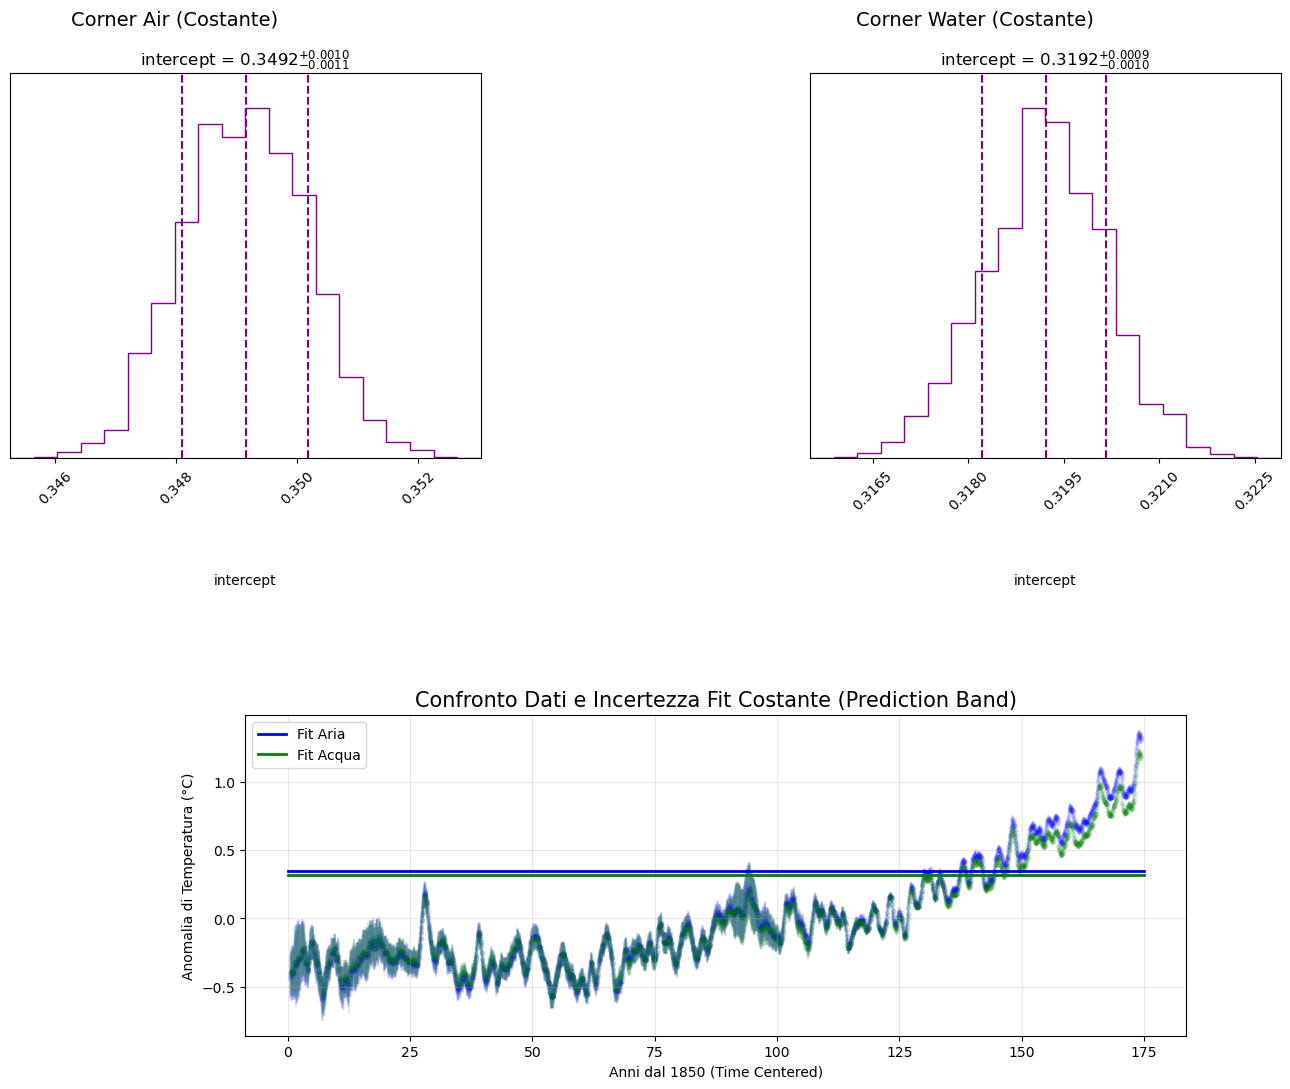

In [25]:
fig = plt.figure(figsize=(16, 12))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.2, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_const'], fig=corner_subfigs[0], title_fmt='.4f')
corner_subfigs[0].suptitle('Corner Air (Costante)', fontsize=14)

cornerplot(results['water_const'], fig=corner_subfigs[1], title_fmt='.4f')
corner_subfigs[1].suptitle('Corner Water (Costante)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def add_constant_band(ax, res_key, data, color, label_name):
    samples = results[res_key]['samples']
    band = PredictionBand(t_grid)

    for val in samples:
        band.add(np.full_like(t_grid, val))
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2, label=f'Fit {label_name}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma (95% approx)

add_constant_band(ax, 'air_const', data_air, 'blue', 'Aria')
add_constant_band(ax, 'water_const', data_water, 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Costante (Prediction Band)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

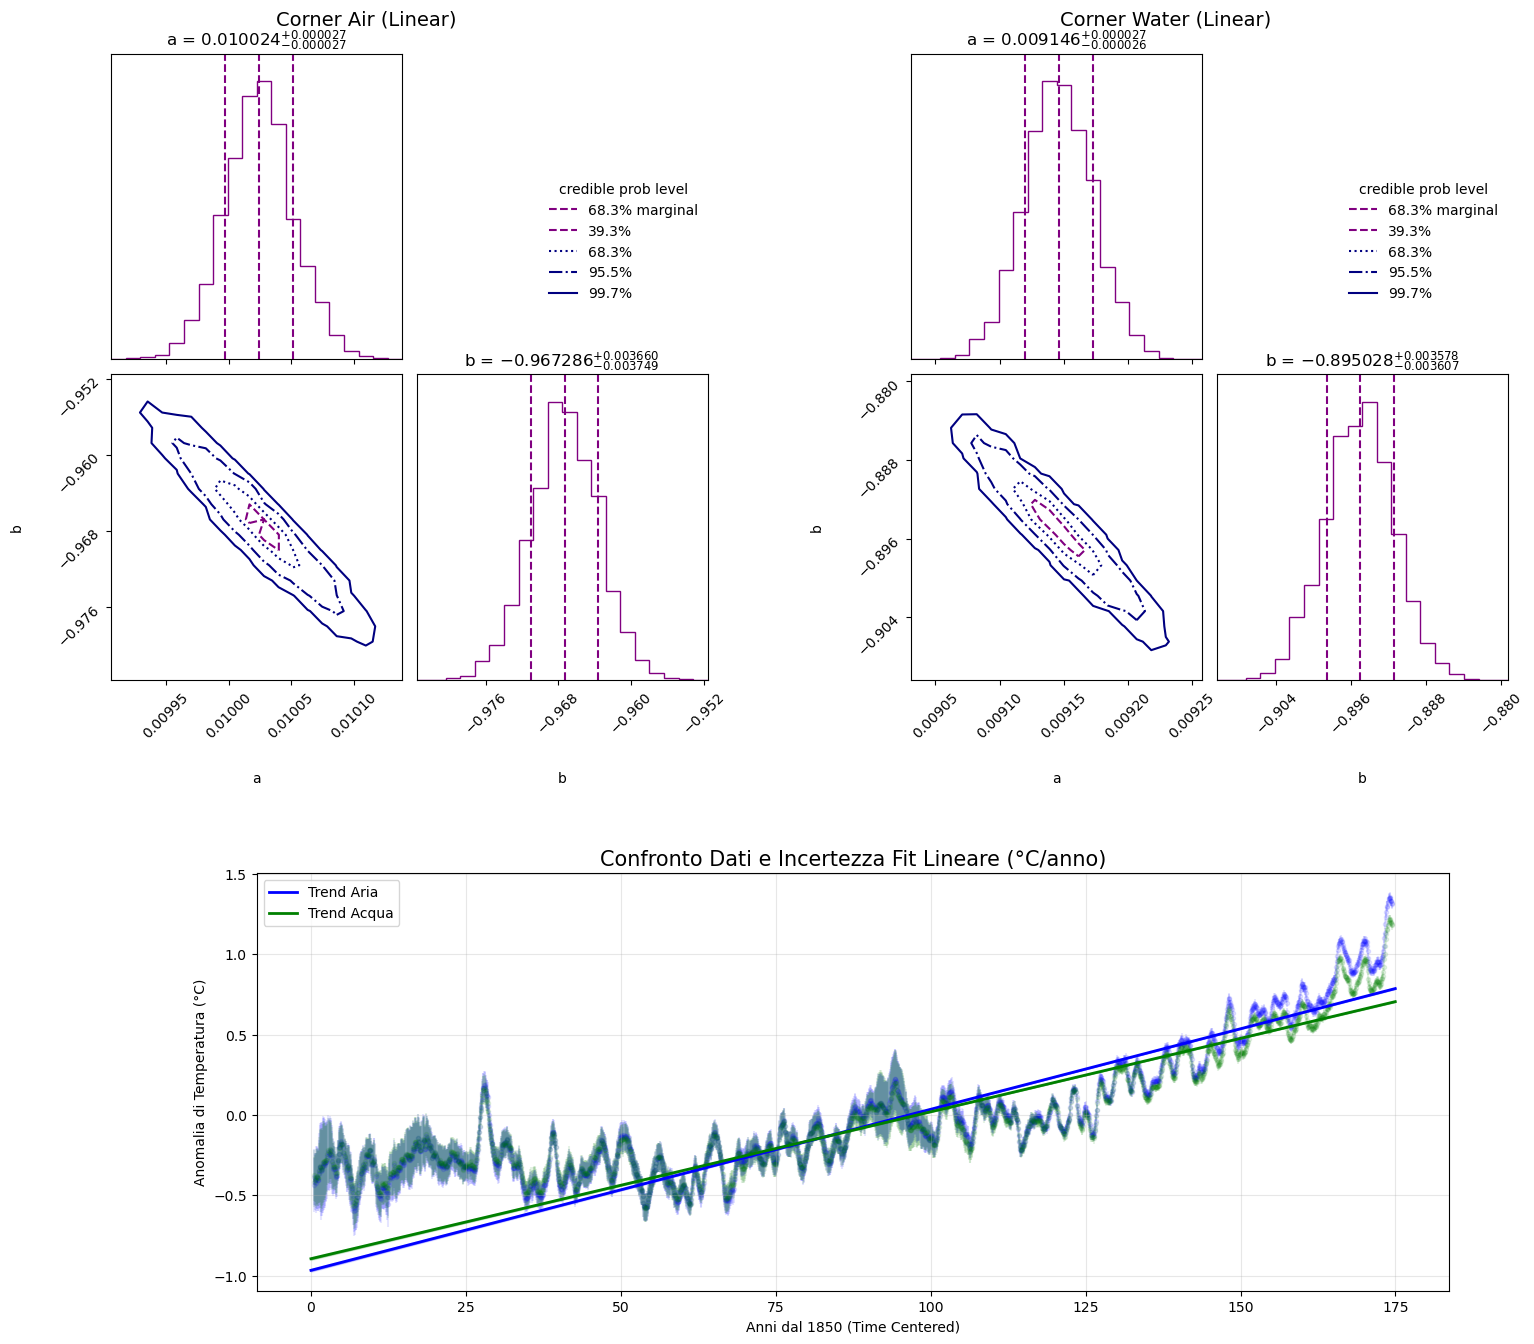

In [26]:
fig = plt.figure(figsize=(16, 14))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.5, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_linear'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Linear)', fontsize=14)

cornerplot(results['water_linear'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Linear)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_linear_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    for a, b in samples:
        band.add(a * t_grid + b)
        
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2, label=f'Trend {label_prefix}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma

plot_linear_with_bands(ax, data_air, 'air_linear', 'blue', 'Aria')
plot_linear_with_bands(ax, data_water, 'water_linear', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Lineare (°C/anno)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

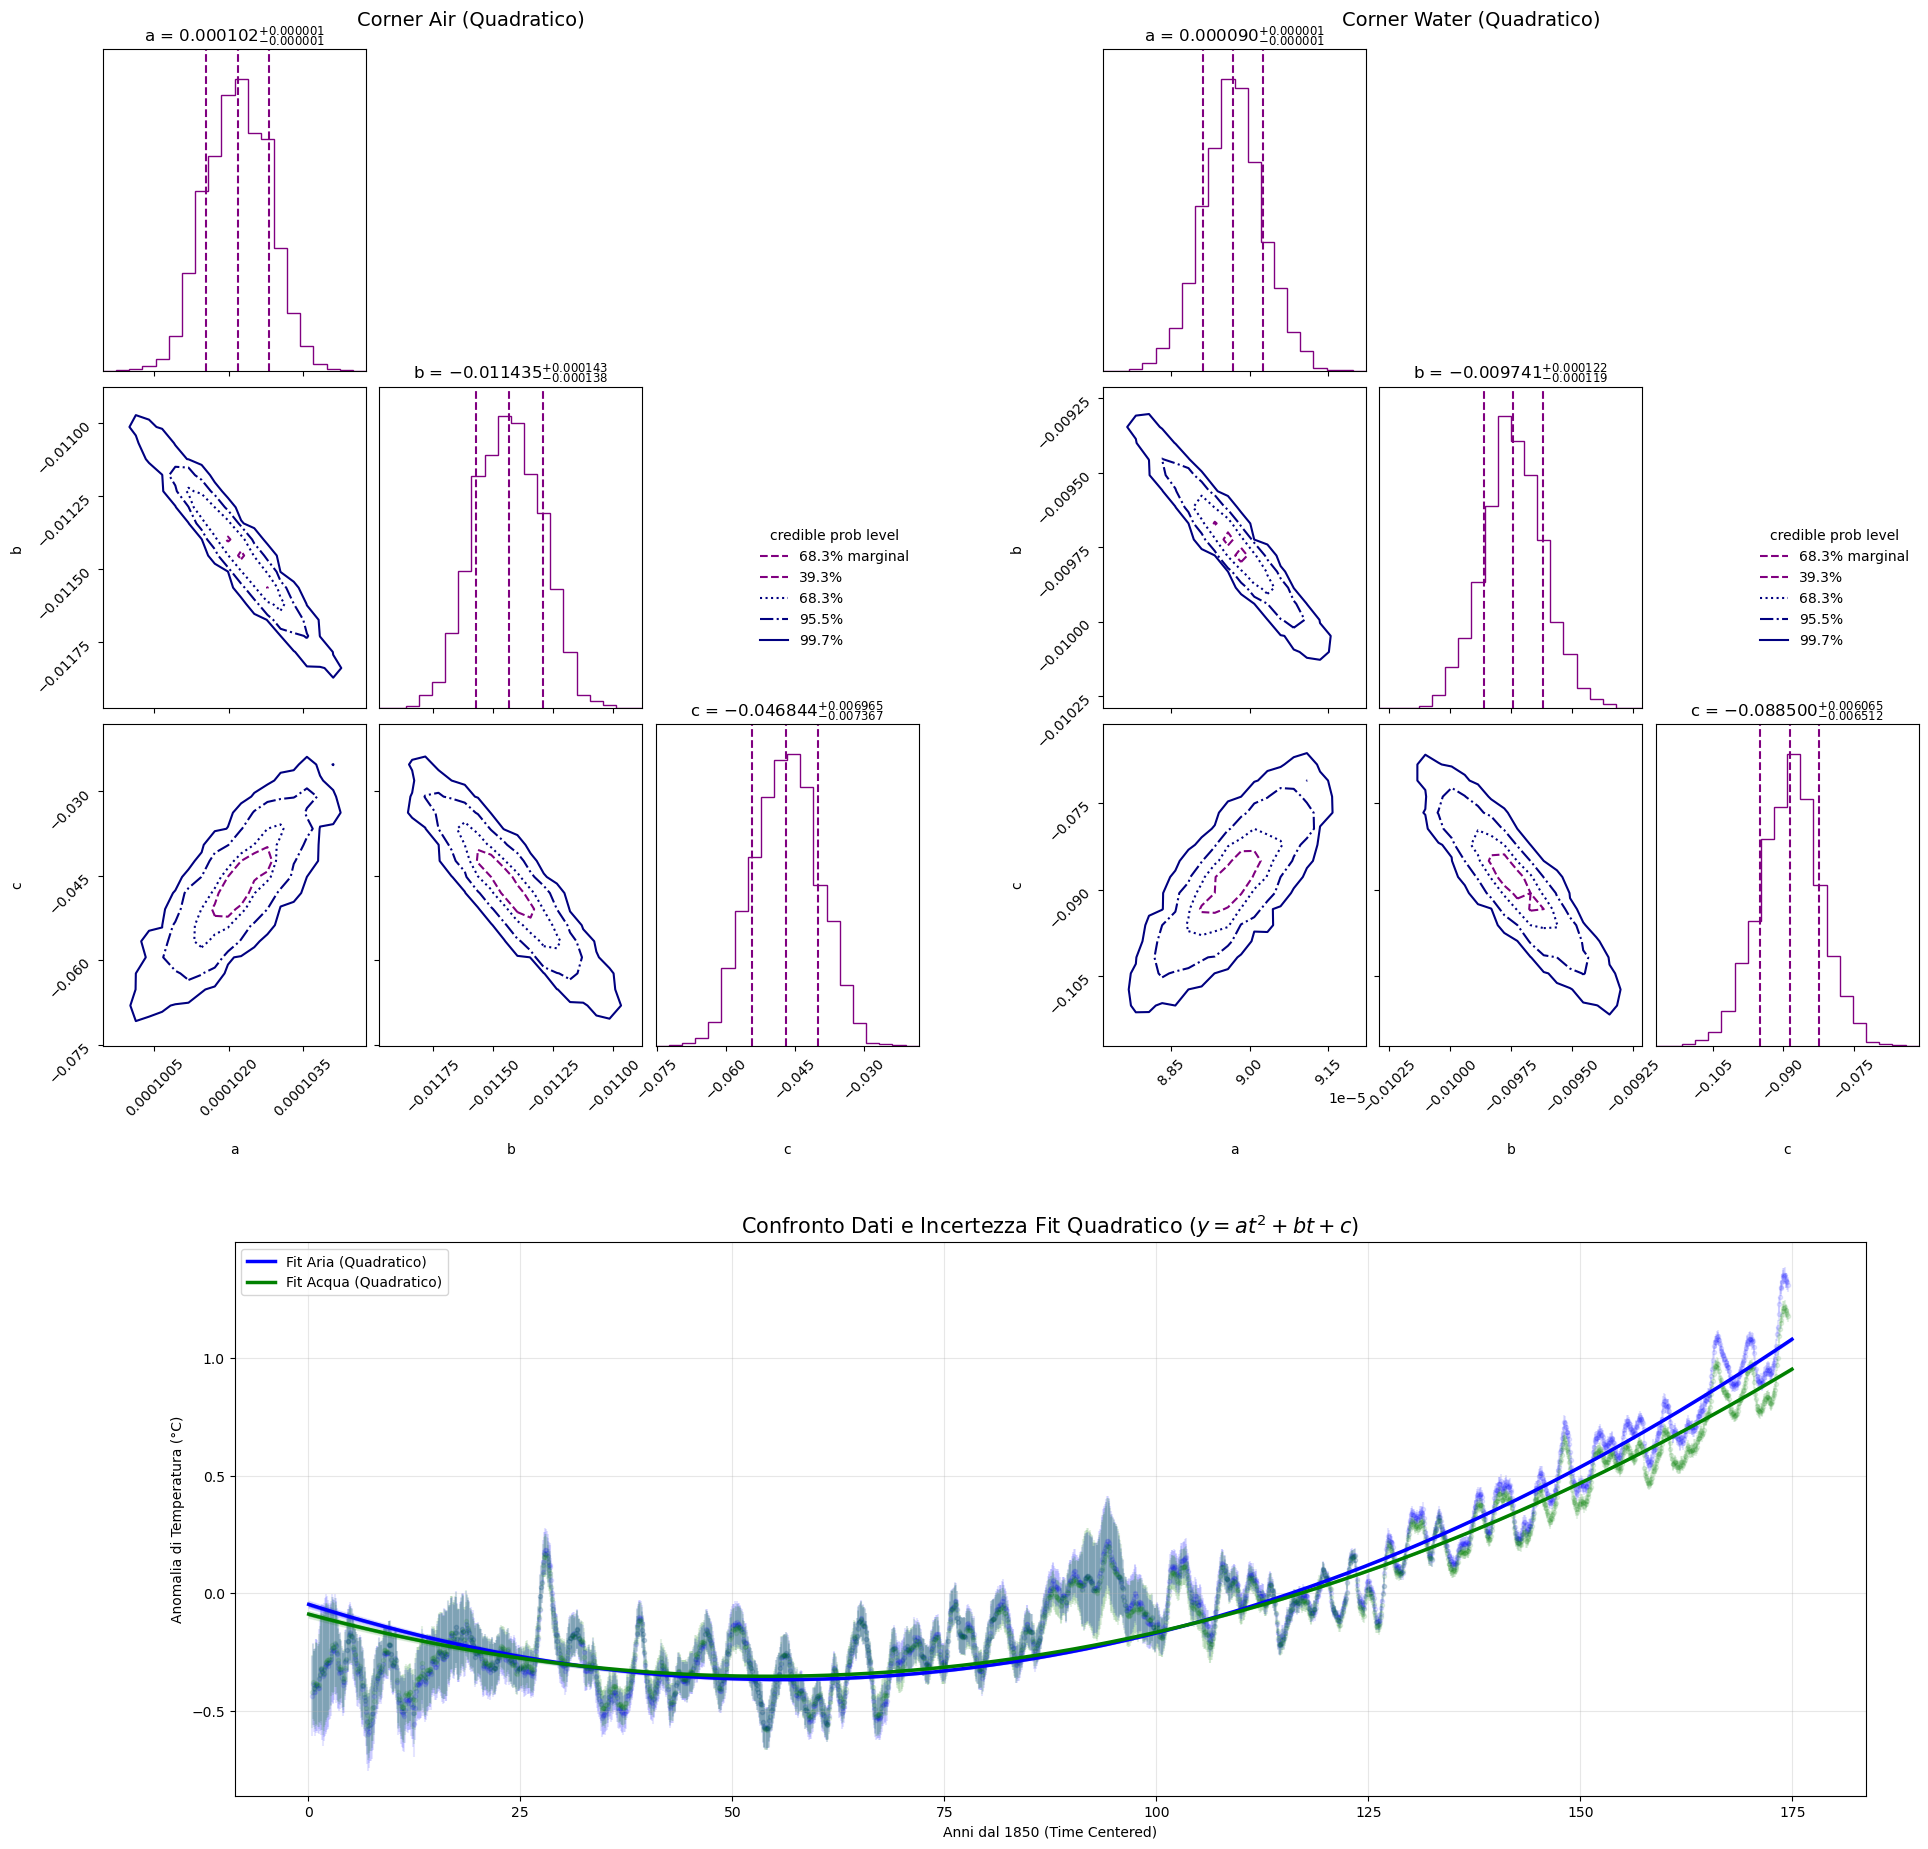

In [27]:
fig = plt.figure(figsize=(20, 19))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_quadratic'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Quadratico)', fontsize=14)

cornerplot(results['water_quadratic'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Quadratico)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_quadratic_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']
    
    band = PredictionBand(t_grid)
    
    for a, b, c in samples:
        band.add(a * t_grid**2 + b * t_grid + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)

    band.line(ax=ax, color=color, lw=2.5, label=f'Fit {label_prefix} (Quadratico)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_quadratic_with_bands(ax, data_air, 'air_quadratic', 'blue', 'Aria')
plot_quadratic_with_bands(ax, data_water, 'water_quadratic', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Quadratico ($y = at^2 + bt + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

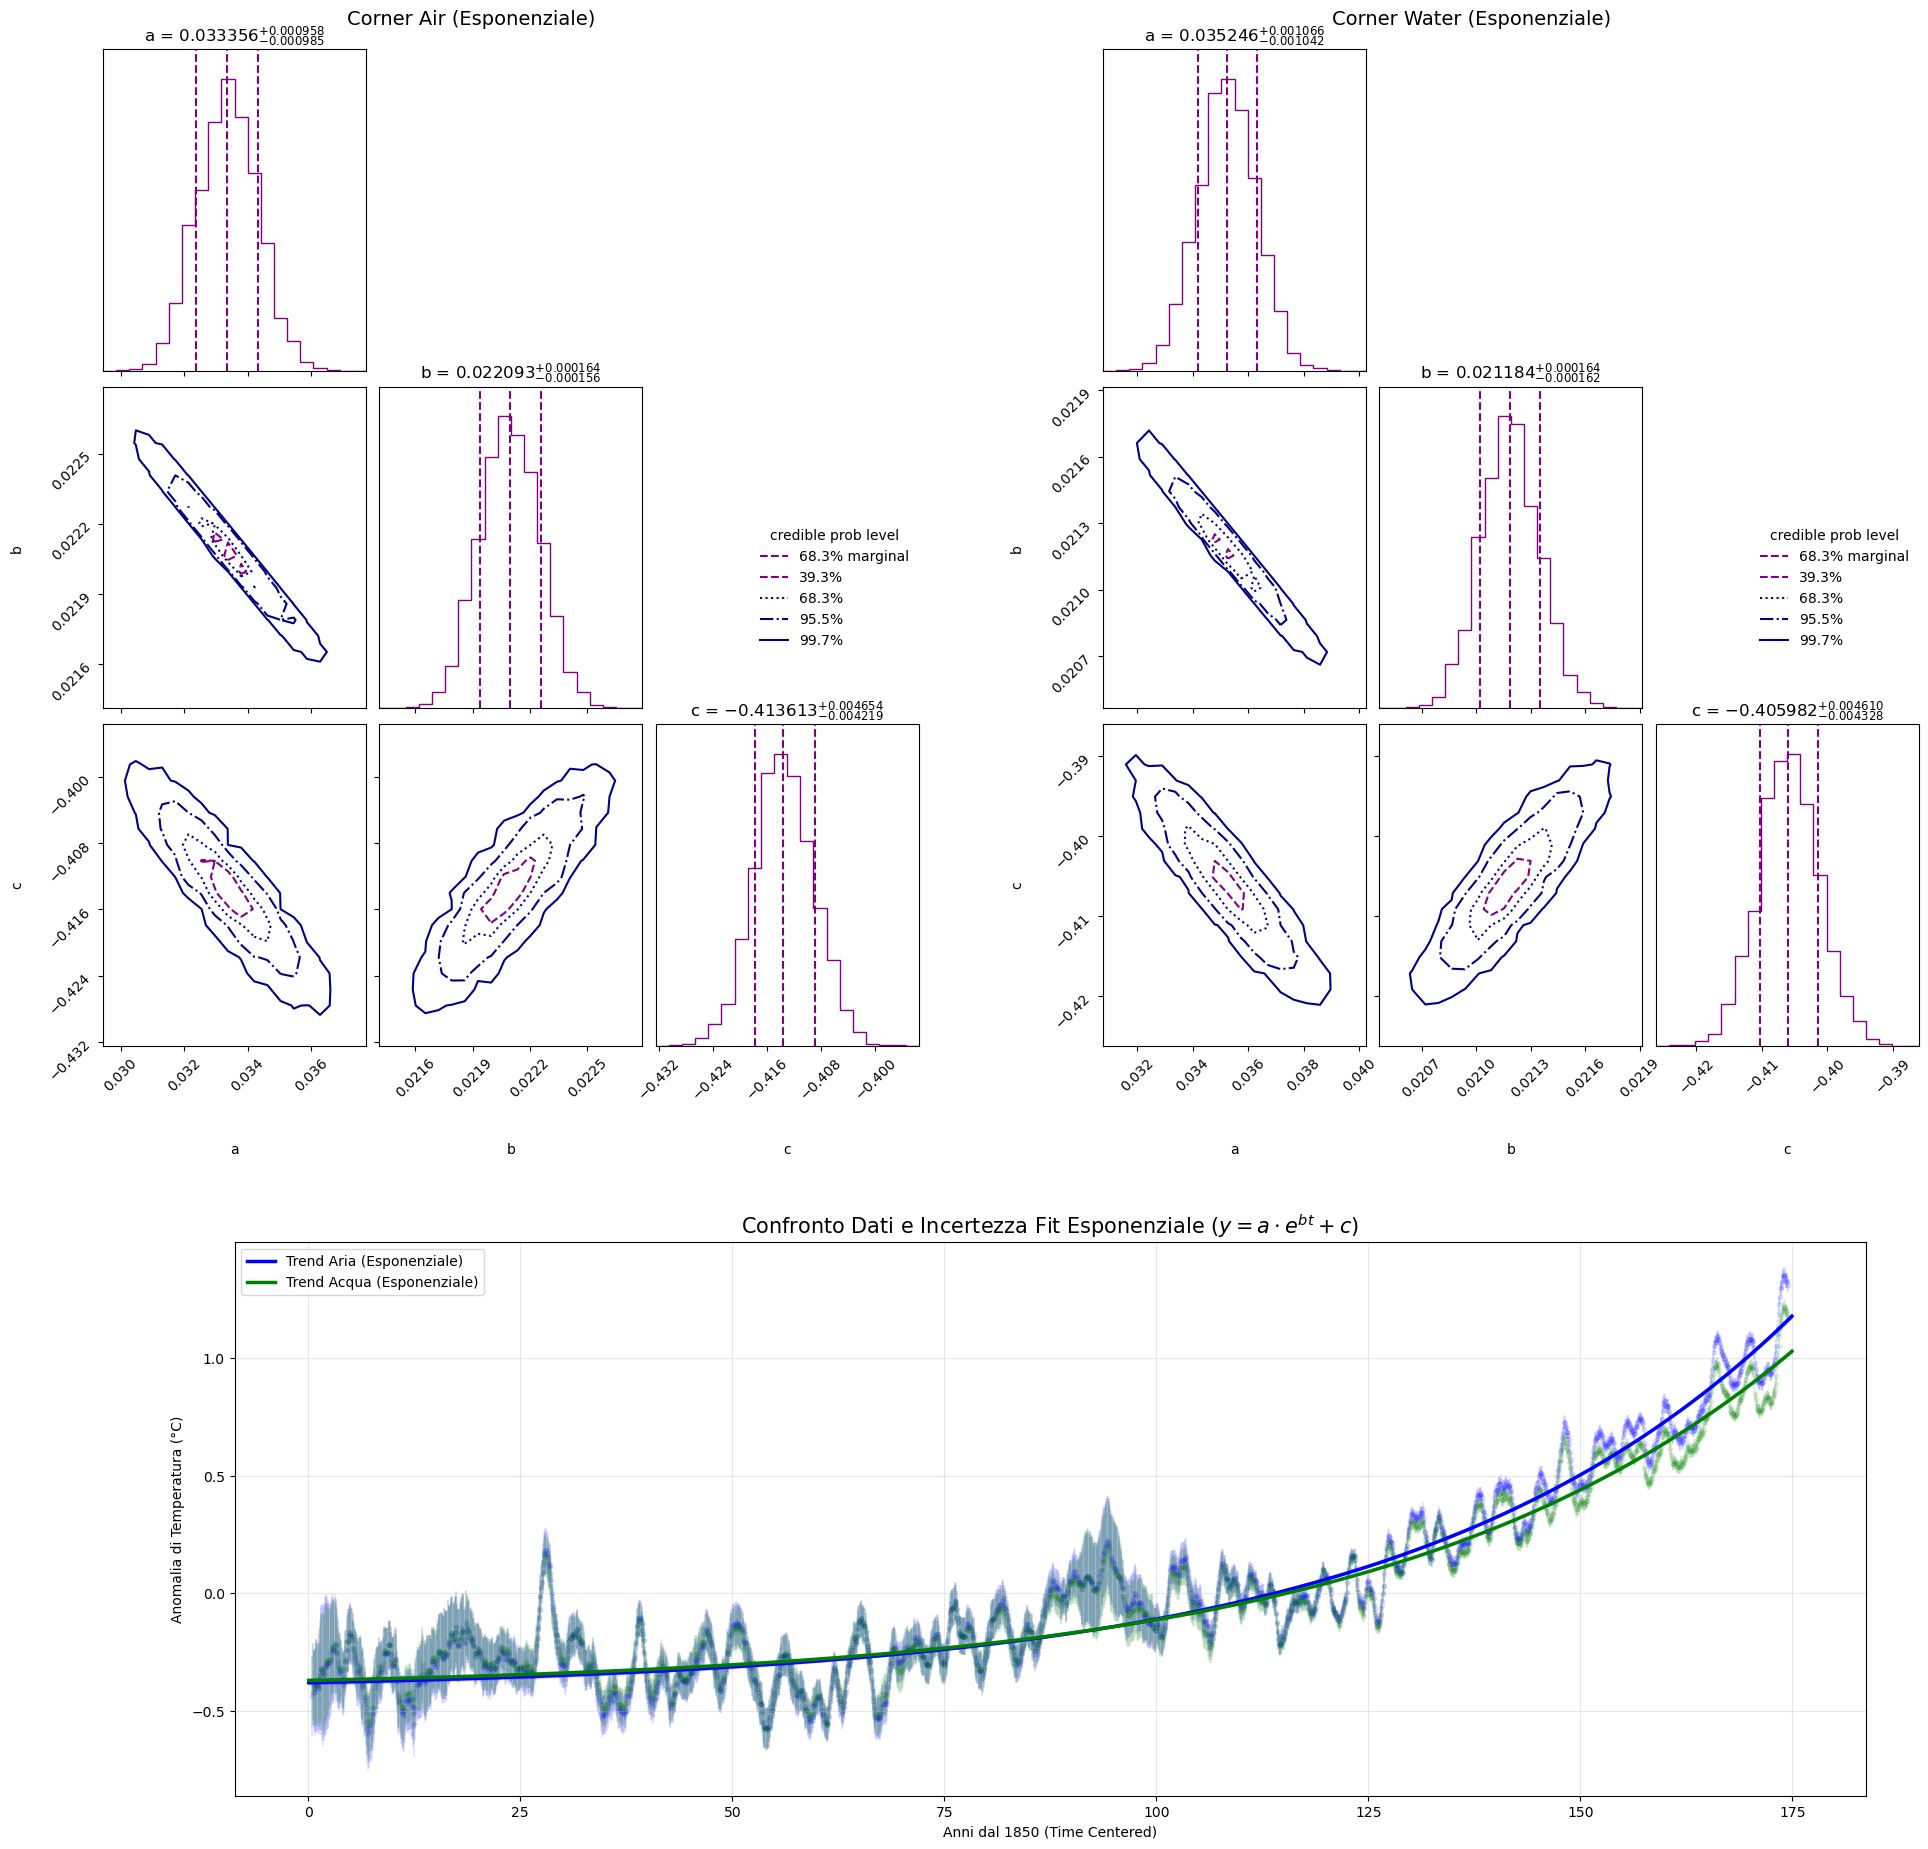

In [28]:
fig = plt.figure(figsize=(20, 19))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_exponential'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Esponenziale)', fontsize=14)

cornerplot(results['water_exponential'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Esponenziale)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_exponential_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    for a, b, c in samples:
        band.add(a * np.exp(b * t_grid) + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2.5, label=f'Trend {label_prefix} (Esponenziale)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_exponential_with_bands(ax, data_air, 'air_exponential', 'blue', 'Aria')
plot_exponential_with_bands(ax, data_water, 'water_exponential', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Esponenziale ($y = a \cdot e^{bt} + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

In [35]:
dataset_labels = ['air', 'water']
model_labels = ['const', 'linear', 'quadratic', 'exponential']

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_const"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = LINEARE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_linear"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = QUADRATICO): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_quadratic"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = ESPONENZIALE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_exponential"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")


--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): AIR ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -81424.88 |         0.00
linear          |    -20206.06 |     61218.82
quadratic       |     -2172.86 |     79252.03
exponential     |     -1703.66 |     79721.22

--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): WATER ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -74219.76 |         0.00
linear          |    -18250.67 |     55969.09
quadratic       |     -1983.12 |     72236.64
exponential     |     -1709.71 |     72510.05

--- CONFRONTO MODELLI PER DATASET (REF = LINEARE): AIR ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -81424.88 |    -61218.82
linear          |    -20206.06 |         0.00
quadratic       |     -2172.86 |     18033.21
exponential     |     -1703.66 |  

In [ ]:
mean_uncert = np.nanmean(data_air['Annual_Anomaly_Unc'])

kernel = mean_uncert * kernels.ExpSquaredKernel(metric=1.0, ndim=1, axes=0)
gp = george.GP(kernel)

data_air_sliced = {k: v[6:] for k, v in data_air.items()}

t_temp = data_air_sliced['time_centered']
u_temp = data_air_sliced['Annual_Anomaly_Unc']
y_temp = data_air_sliced['Annual_Anomaly']

mask = (~np.isnan(t_temp)) & (~np.isinf(t_temp)) & \
       (~np.isnan(u_temp)) & (~np.isinf(u_temp)) & \
       (~np.isnan(y_temp)) & (~np.isinf(y_temp))
 
data_air_fixed = {k: v[mask] for k, v in data_air_sliced.items()}
gp.compute(data_air_fixed['time_centered'], data_air_fixed['Annual_Anomaly_Unc'])

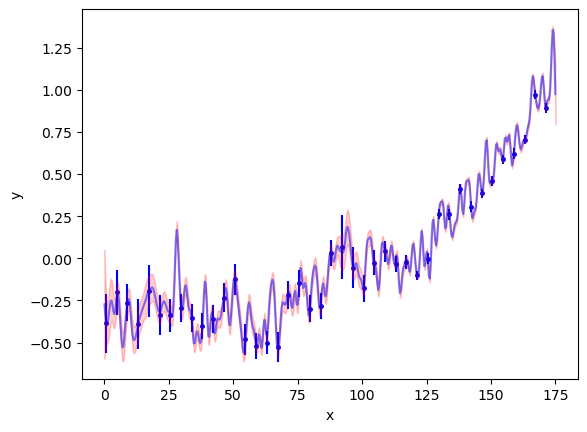

In [85]:
x_pred = np.linspace(0, 175, 500)
y = data_air_fixed['Annual_Anomaly']
yerr = data_air_fixed['Annual_Anomaly_Unc']
x = data_air_fixed['time_centered']
pred, pred_var = gp.predict(y, x_pred, return_var=True)

plt.fill_between(x_pred, pred - 2*np.sqrt(pred_var), pred + 2*np.sqrt(pred_var),
                color="r", alpha=0.2, zorder=2)
plt.plot(x_pred, pred, "b", lw=1.5, alpha=0.5, label='GP Prediction', zorder=3)
#plt.errorbar(x, y, yerr=yerr, fmt=".g", capsize=0, markersize=1, label='Dati Aria', zorder=1)
step = 50 
plt.errorbar(x[::step], y[::step], yerr=yerr[::step], 
             fmt=".b", capsize=0, markersize=5, label=f'Dati (1/{step})', zorder=1)
plt.xlabel("x")
plt.ylabel("y");

In [88]:
print("Initial ln-likelihood: {0:.2f}".format(gp.log_likelihood(y)))

def neg_ln_like(p):
    gp.set_parameter_vector(p)
    return -gp.log_likelihood(y)

def grad_neg_ln_like(p):
    gp.set_parameter_vector(p)
    return -gp.grad_log_likelihood(y)

result = minimize(neg_ln_like, gp.get_parameter_vector(), jac=grad_neg_ln_like)
print(result)

gp.set_parameter_vector(result.x)
print("\nFinal ln-likelihood: {0:.2f}".format(gp.log_likelihood(y)))

Initial ln-likelihood: 3158.94
  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -3165.8291104409846
        x: [-2.271e+00 -5.646e-02]
      nit: 6
      jac: [ 7.188e-06 -1.984e-05]
 hess_inv: [[ 1.322e-02  2.071e-03]
            [ 2.071e-03  2.079e-03]]
     nfev: 42
     njev: 30

Final ln-likelihood: 3165.83


In [100]:
class Exponential_Trend(Model):
    parameter_names = ['a', 'b', 'c']

    def get_value(self, t):
        return self.a * np.exp(self.b * t) + self.c

model = george.GP(mean=Exponential_Trend(a=0.3, b=0.2, c=-0.4))
model.compute(x, yerr)

def log_prior(cube):
    params = cube.copy()
    params[0] = cube[0] * 2.0
    params[1] = cube[1] * 0.05
    params[2] = cube[2] * 10 - 5
    return params

def log_l(p):
    model.set_parameter_vector(p)
    return model.log_likelihood(y, quiet=True)


param_names = list(model.get_parameter_names())
sampler_final = ReactiveNestedSampler(param_names, loglike=log_l, transform=log_prior)
final_res = sampler_final.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-2e+03  681.96 [-1682.0238..-1682.0238]*| it/evals=10640/93004 eff=11.4898% N=400   0   0   
[ultranest] Likelihood function evaluations: 93063
[ultranest]   logZ = -1704 +- 0.1814
[ultranest] Effective samples strategy satisfied (ESS = 1937.8, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.


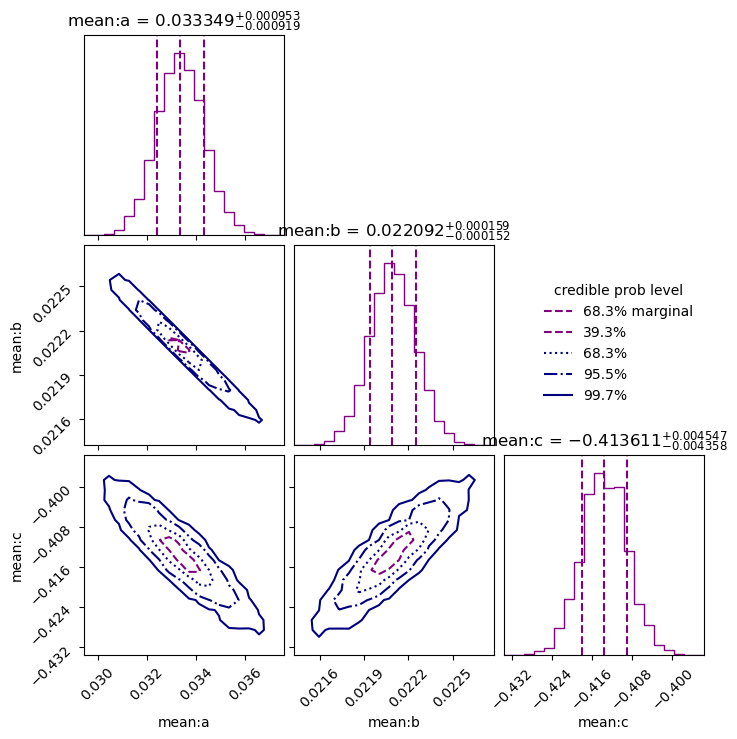

In [102]:
cornerplot(final_res, title_fmt='.6f');